# Comparación de modelos de machine learning para la predicción de cáncer de pulmón

## Importación de librerías y modelos

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import optuna

from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

print("Librerías importadas correctamente")

c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Librerías importadas correctamente


## Proceso ETL y visualizaciones

### Carga de Dataset

In [2]:
DATA_PATH = "data/dataset.csv"

df = pd.read_csv(DATA_PATH, sep=";")
print(f"Cantidad de datos: {df.shape[0]}")
df.head()

Cantidad de datos: 3309


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,LUNG_CANCER
0,M,65,1,1,1,2,2,1,2,2,2,2,2,2,1,NO
1,F,55,1,2,2,1,1,2,2,2,1,1,1,2,2,NO
2,F,78,2,2,1,1,1,2,1,2,1,1,2,1,1,YES
3,M,60,2,1,1,1,2,1,2,1,1,2,1,2,2,YES
4,F,80,1,1,2,1,1,2,1,2,1,1,1,1,2,NO


In [3]:
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3309 entries, 0 to 3308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 3309 non-null   object
 1   AGE                    3309 non-null   int64 
 2   SMOKING                3309 non-null   int64 
 3   YELLOW_FINGERS         3309 non-null   int64 
 4   ANXIETY                3309 non-null   int64 
 5   PEER_PRESSURE          3309 non-null   int64 
 6   CHRONIC_DISEASE        3309 non-null   int64 
 7   FATIGUE                3309 non-null   int64 
 8   ALLERGY                3309 non-null   int64 
 9   WHEEZING               3309 non-null   int64 
 10  ALCOHOL_CONSUMING      3309 non-null   int64 
 11  COUGHING               3309 non-null   int64 
 12  SHORTNESS_OF_BREATH    3309 non-null   int64 
 13  SWALLOWING_DIFFICULTY  3309 non-null   int64 
 14  CHEST_PAIN             3309 non-null   int64 
 15  LUNG_CANCER          

### Conversión a binario

- Variables clínicas:
  1 = No  → 0
  2 = Sí  → 1

- Género:
  F (Femenino) → 0
  M (Masculino) → 1

In [4]:
# Revisar
binary_cols = [
    'SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE',
    'CHRONIC_DISEASE', 'FATIGUE', 'ALLERGY', 'WHEEZING',
    'ALCOHOL_CONSUMING', 'COUGHING', 'SHORTNESS_OF_BREATH',
    'SWALLOWING_DIFFICULTY', 'CHEST_PAIN'
]

for col in binary_cols:
    df[col] = df[col].map({2:1, 1:0})

df['GENDER'] = df['GENDER'].map({'M': 1, 'F': 0})
df['LUNG_CANCER'] = df['LUNG_CANCER'].map({'YES': 1, 'NO': 0})

In [5]:
for col in df.columns:
    print(col, df[col].unique())

GENDER [1 0]
AGE [65 55 78 60 80 58 70 74 77 67 35 79 39 62 64 66 76 48 33 47 50 36 37 51
 53 72 71 54 41 46 59 32 34 44 38 69 45 40 63 75 52 31 57 73 42 56 68 61
 30 49 43 21 81 87]
SMOKING [0 1]
YELLOW_FINGERS [0 1]
ANXIETY [0 1]
PEER_PRESSURE [1 0]
CHRONIC_DISEASE [1 0]
FATIGUE [0 1]
ALLERGY [1 0]
WHEEZING [1 0]
ALCOHOL_CONSUMING [1 0]
COUGHING [1 0]
SHORTNESS_OF_BREATH [1 0]
SWALLOWING_DIFFICULTY [1 0]
CHEST_PAIN [0 1]
LUNG_CANCER [0 1]


In [6]:
print(df.dtypes)

GENDER                   int64
AGE                      int64
SMOKING                  int64
YELLOW_FINGERS           int64
ANXIETY                  int64
PEER_PRESSURE            int64
CHRONIC_DISEASE          int64
FATIGUE                  int64
ALLERGY                  int64
WHEEZING                 int64
ALCOHOL_CONSUMING        int64
COUGHING                 int64
SHORTNESS_OF_BREATH      int64
SWALLOWING_DIFFICULTY    int64
CHEST_PAIN               int64
LUNG_CANCER              int64
dtype: object


In [7]:
df.describe()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,LUNG_CANCER
count,3309.000000,3309.000000,3309.000000,3309.000000,3309.000000,3309.000000,3309.000000,3309.000000,3309.000000,3309.000000,3309.000000,3309.000000,3309.000000,3309.000000,3309.000000,3309.000000
mean,0.506497,55.869749,0.497733,0.519190,0.494409,0.499244,0.509217,0.506800,0.511333,0.502871,0.497431,0.517075,0.502267,0.487761,0.504080,0.540345
std,0.500033,14.407765,0.500070,0.499707,0.500044,0.500075,0.499991,0.500029,0.499947,0.500067,0.500069,0.499784,0.500070,0.499926,0.500059,0.498445
min,0.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,44.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,56.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000
75%,1.000000,68.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,87.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Histogramas
No hay presencia de outliers

In [8]:
def histogramas(columna):
  fig, ax = plt.subplots(figsize=(10,4))
  df[columna].hist(bins=30, edgecolor="b")
  ax.set_title(columna, size=25)
  df[columna].describe().round(2)

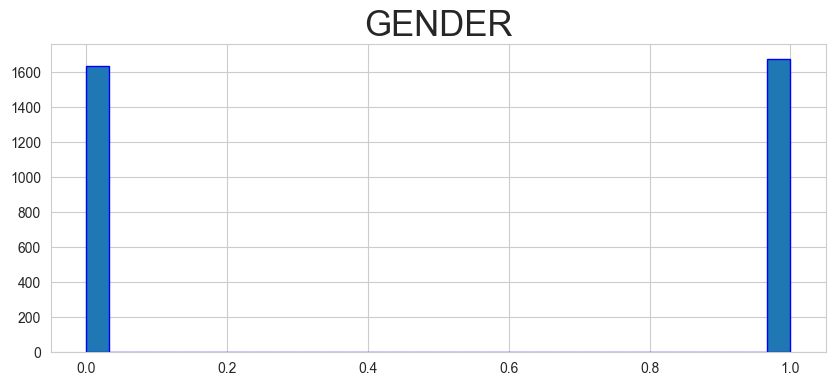

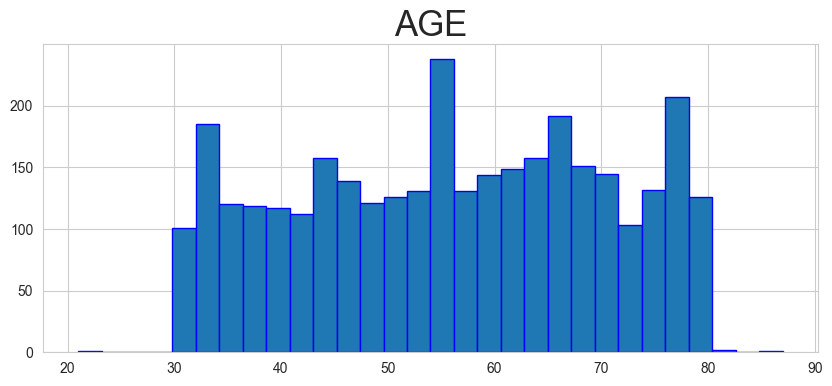

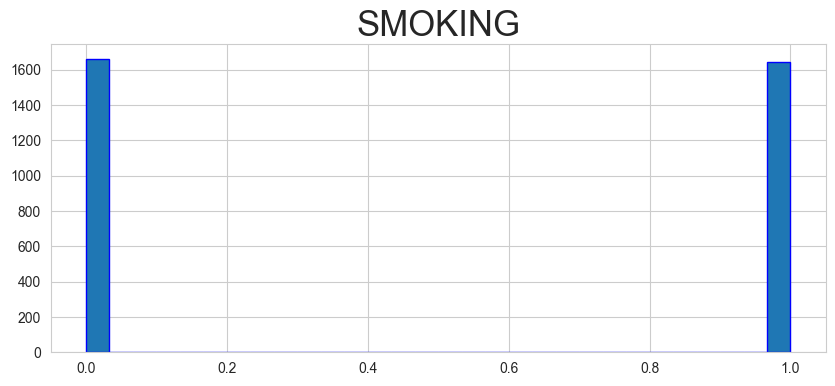

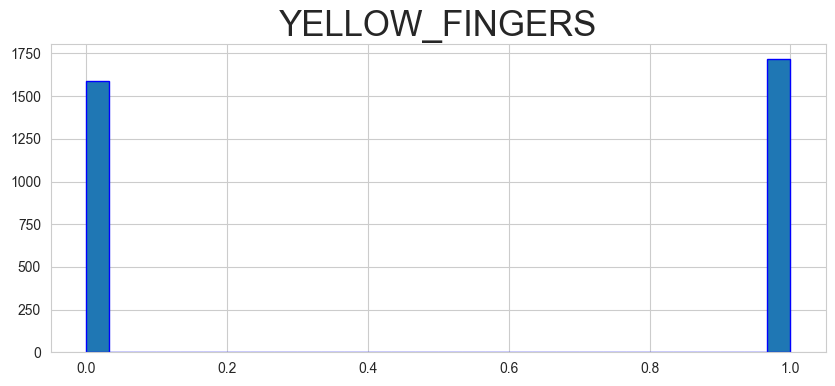

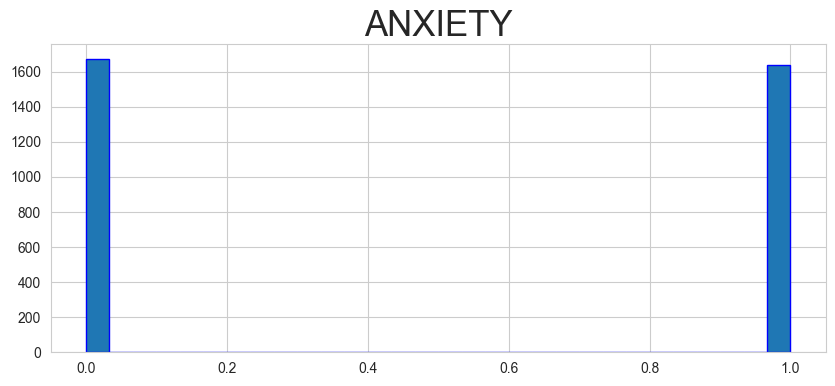

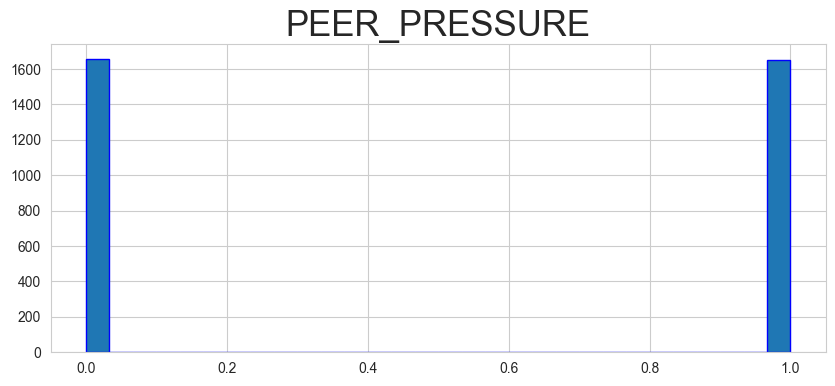

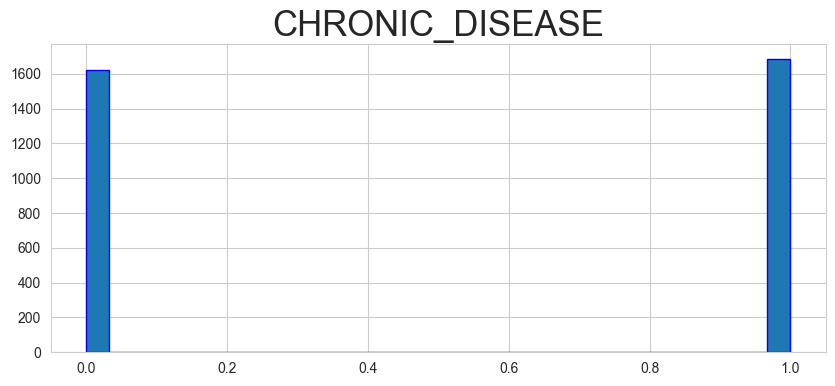

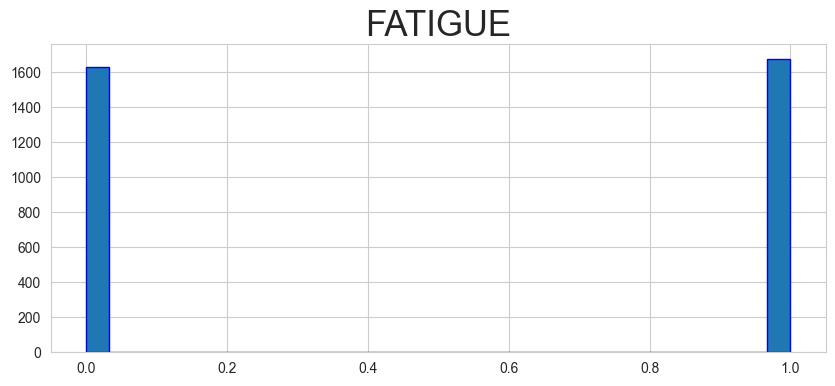

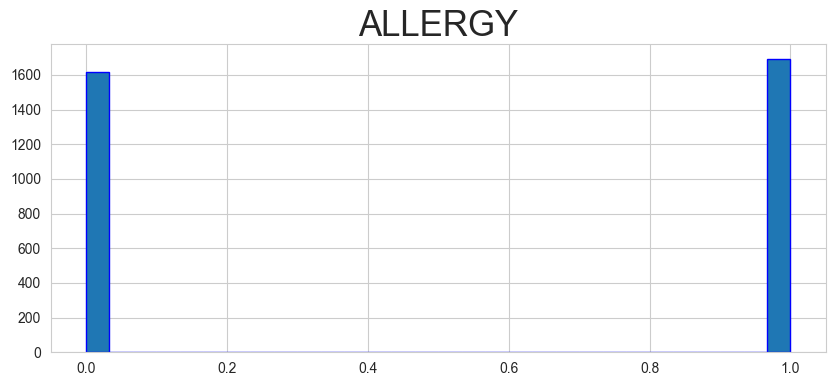

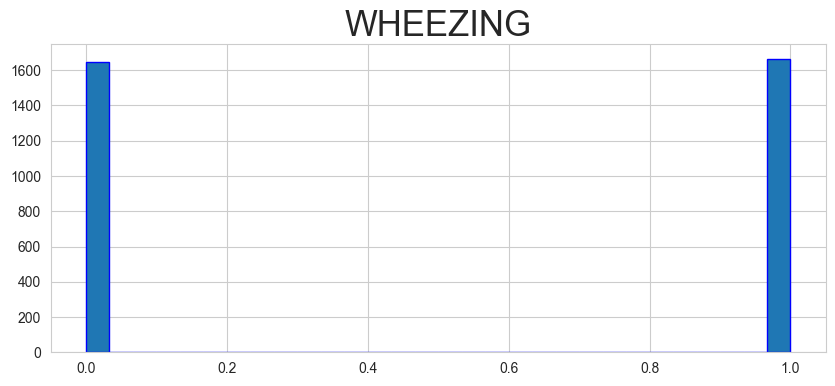

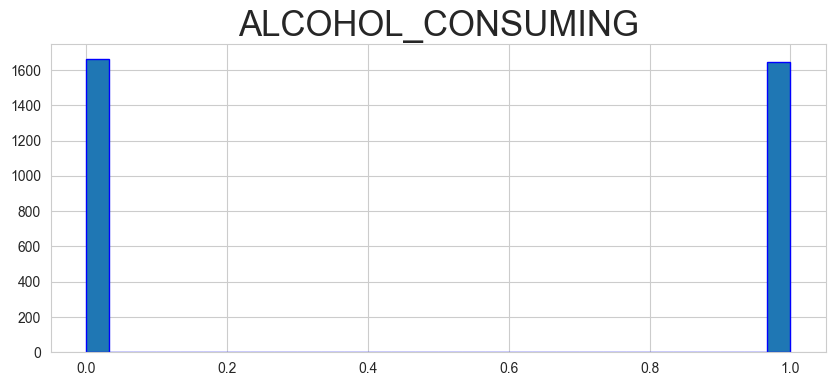

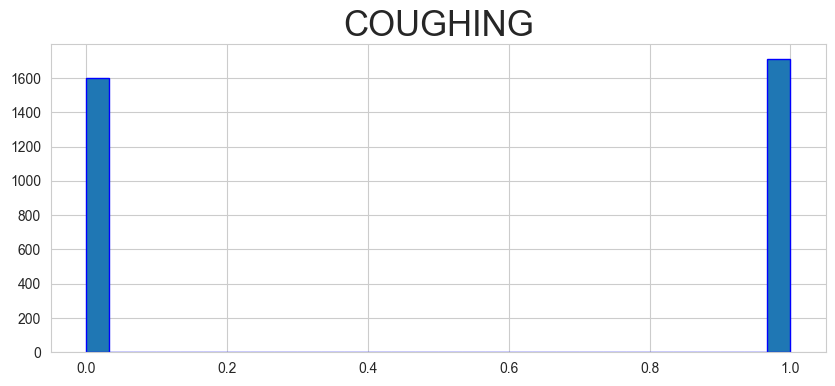

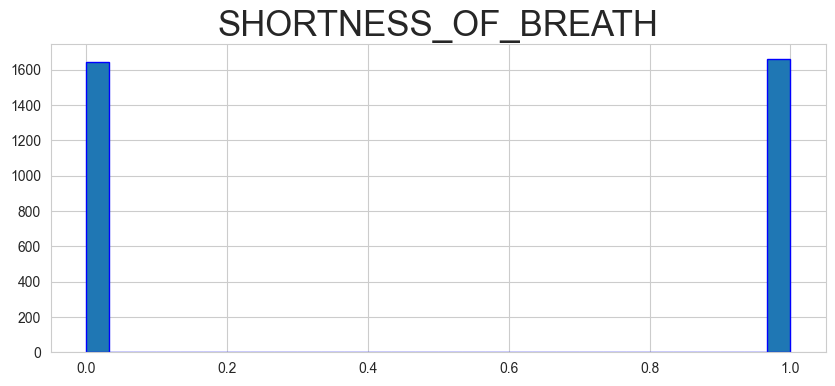

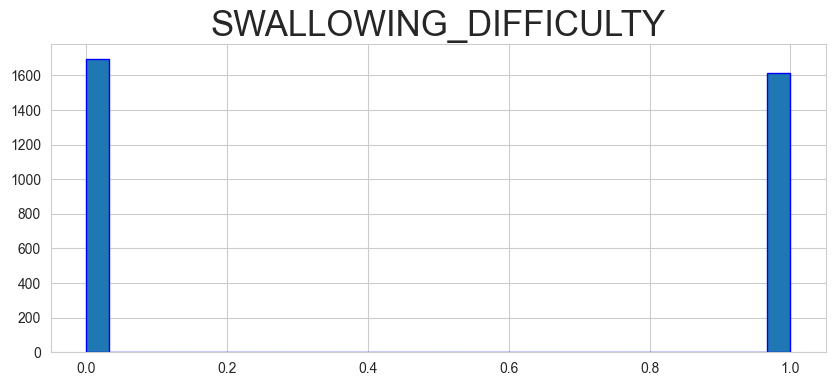

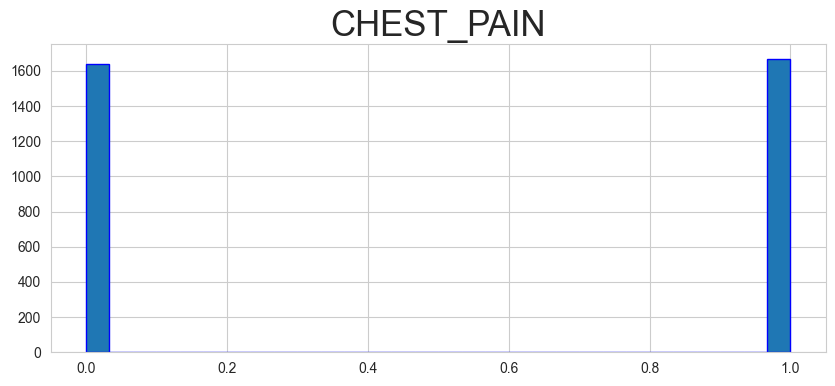

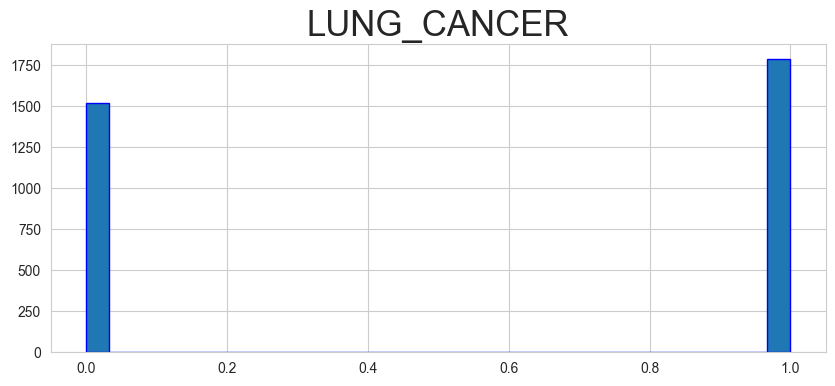

In [9]:
for x in df.columns:
  histogramas(x)

### Matriz de correlación
No existe una correlación fuerte en ninguna variable

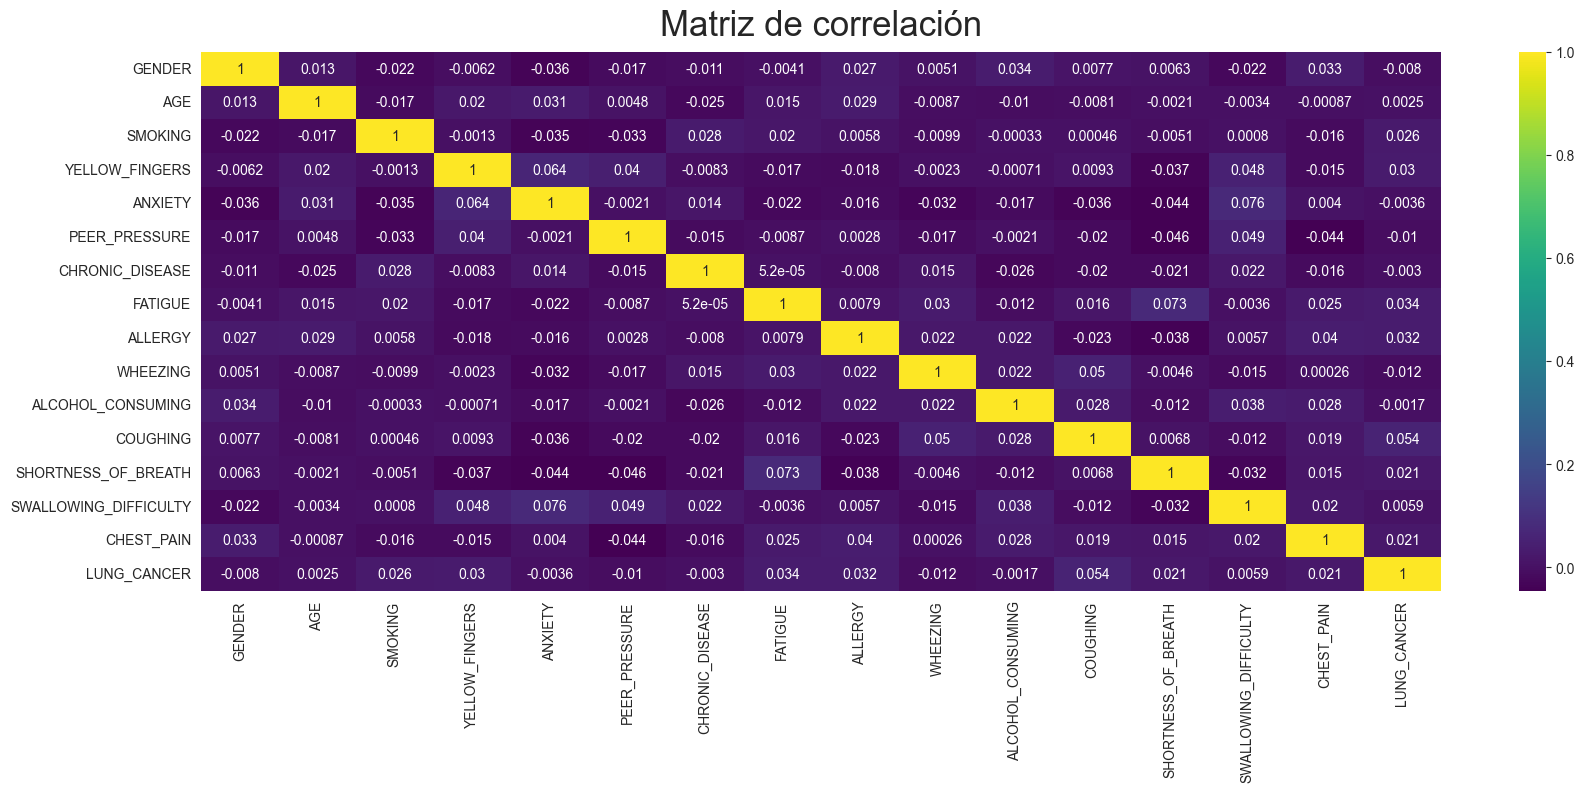

In [10]:
plt.figure(figsize=(20,7))
heatmap = sns.heatmap(df.corr(), cmap='viridis', annot=True)
heatmap.set_title('Matriz de correlación', fontdict={'fontsize':25}, pad=12);

Correlación solo con LUNG_CANCER

<Axes: ylabel='None'>

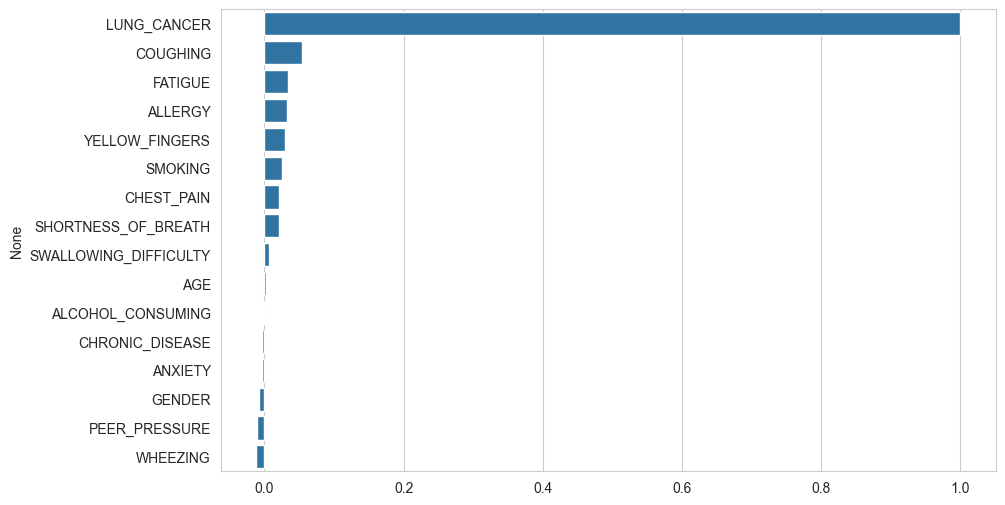

In [13]:
corr_with_target = df.corr()['LUNG_CANCER'].sort_values(ascending=False)
sns.barplot(x=corr_with_target.values, y=corr_with_target.index)

### Densidad de la edad por clase

<Axes: xlabel='AGE', ylabel='Density'>

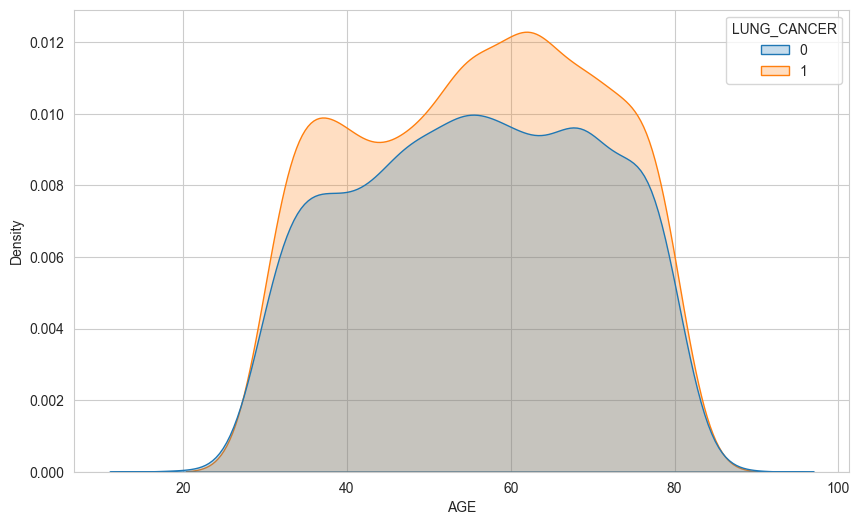

In [14]:
sns.kdeplot(data=df, x='AGE', hue='LUNG_CANCER', fill=True)

## Entrenamiento de modelos predictivos